In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import ipywidgets as widgets
import scipy as sp

In [2]:
%matplotlib widget
plt.close("all")

In [3]:
spettri_dir = "data/spettri/"

available_spettri = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and i != "reference.xy"]

print("Available spettri:")
for i, spectrum in enumerate(available_spettri):
    print(f"{i}: {spectrum}")

Available spettri:
0: campione_9nm_1.xy


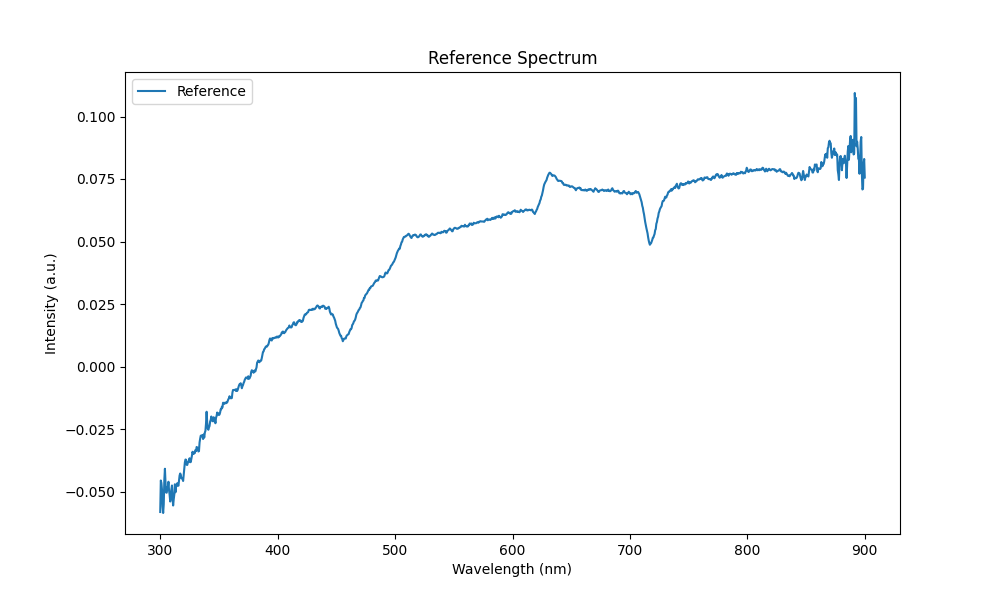

In [4]:
reference_spectrum = np.loadtxt(os.path.join(spettri_dir, "reference.xy"))

reference_avg = np.mean(reference_spectrum[:, 1])

plt.figure(figsize=(10, 6))
plt.plot(reference_spectrum[:, 0], reference_spectrum[:, 1], label="Reference")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference Spectrum")
plt.legend()
plt.show()

In [5]:
file_selector = widgets.Dropdown(
    options=[(sp, sp) for sp in available_spettri],
    description="Select spettri:",
)
display(file_selector)

Dropdown(description='Select spettri:', options=(('campione_9nm_1.xy', 'campione_9nm_1.xy'),), value='campione…

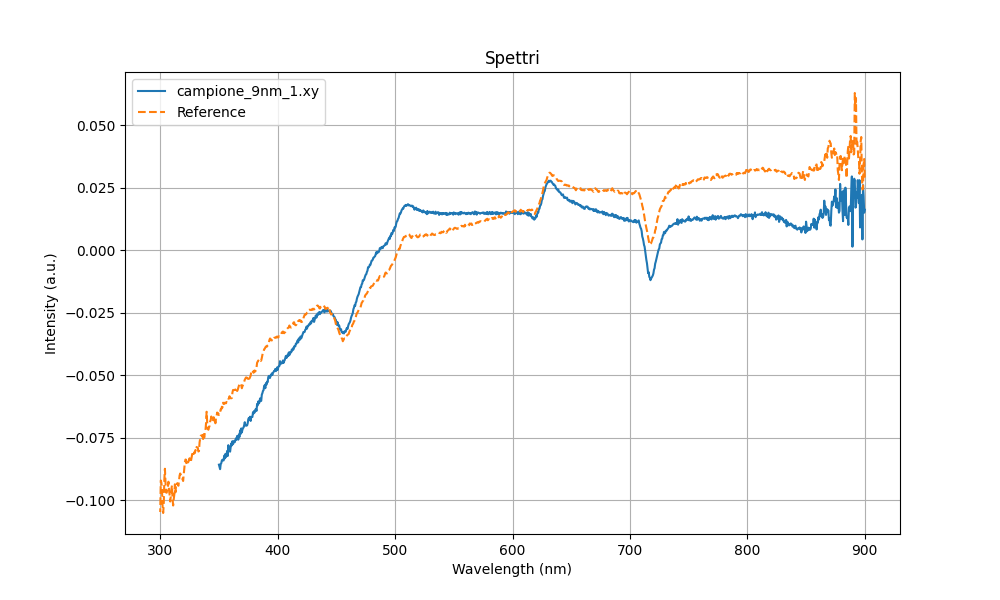

In [6]:
data = np.loadtxt(os.path.join(spettri_dir, file_selector.value))
wavelength = data[:, 0]
intensity = data[:, 1]

intensity_avg = np.mean(intensity)

plt.figure(figsize=(10, 6))
plt.plot(wavelength, intensity - intensity_avg, label=file_selector.value)
plt.plot(reference_spectrum[:, 0], reference_spectrum[:, 1] - reference_avg, label="Reference", linestyle="--")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity (a.u.)")
plt.title("Spettri")
plt.legend()
plt.grid()
plt.show()

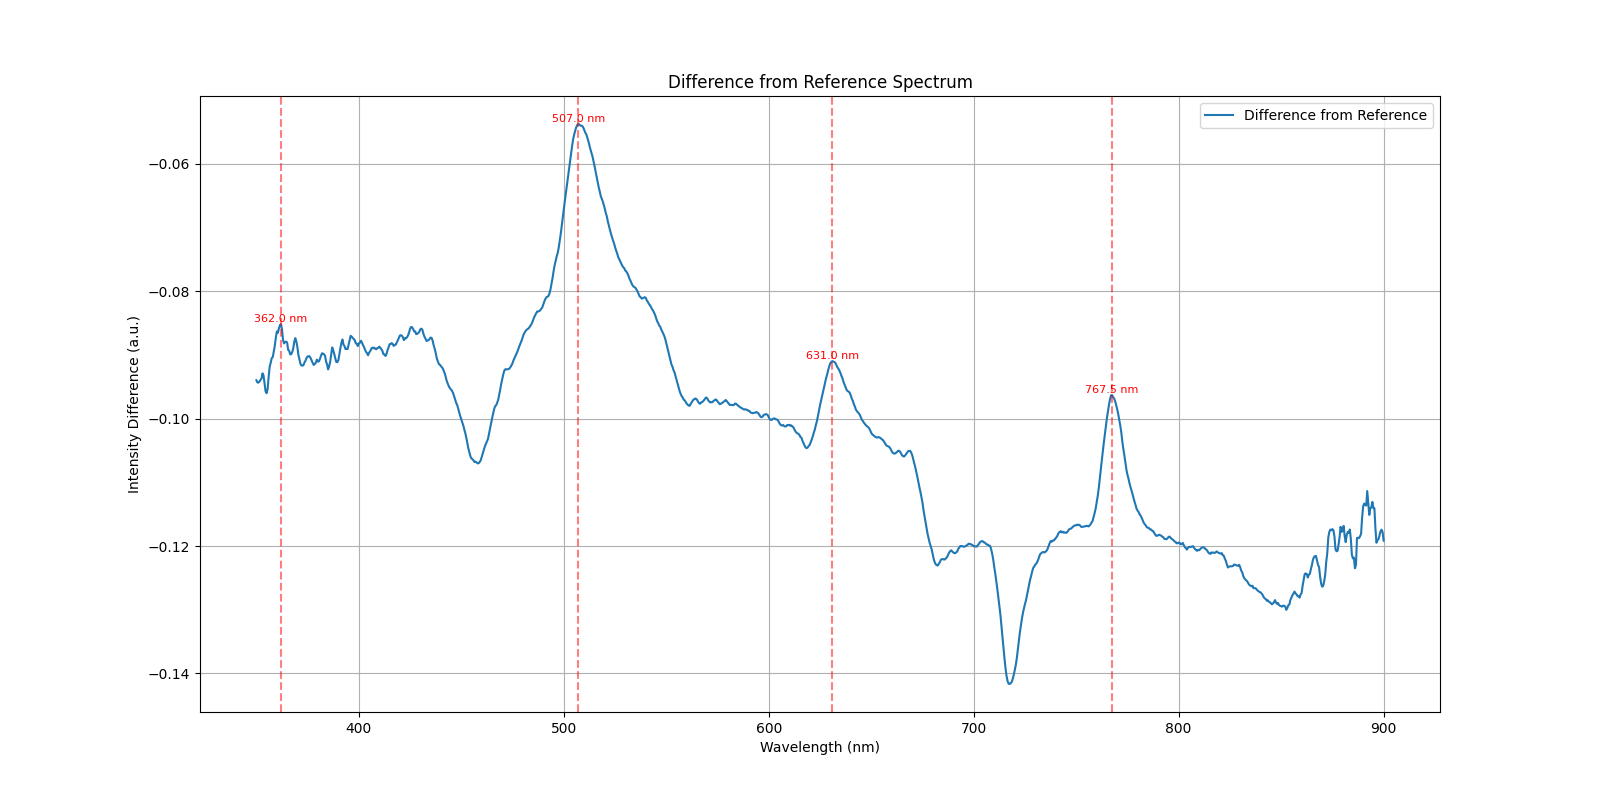

In [9]:
diff_from_reference = (intensity - reference_spectrum[100:, 1])

diff_from_reference_smooth = sp.signal.savgol_filter(diff_from_reference, window_length=11, polyorder=3)

peaks, _ = sp.signal.find_peaks(diff_from_reference_smooth, prominence=0.01)

plt.figure(figsize=(16, 8))
plt.plot(wavelength, diff_from_reference_smooth, label="Difference from Reference")

#plt.plot(wavelength[peaks], diff_from_reference[peaks], "x", label="Peaks")
#plt.axhline(0, color="gray", linestyle="--", label="Reference Level")
for peak in peaks:
    plt.axvline(wavelength[peak], color="red", linestyle="--", alpha=0.5)
    plt.text(wavelength[peak], diff_from_reference_smooth[peak], f"{wavelength[peak]:.1f} nm", color="red", fontsize=8, ha="center", va="bottom")


plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity Difference (a.u.)")
plt.title("Difference from Reference Spectrum")
plt.legend()
plt.grid()
plt.show()